# 🏭 Defect Analysis in Manufacturing Process

## 📌 Business Context
A manufacturing process is experiencing multiple defect types across production batches.  
All recorded observations correspond to defective products, indicating a need to:

- Understand dominant defect types  
- Identify process conditions associated with each defect  
- Detect patterns that explain defect generation  

---

## 🎯 Objective

This analysis aims to:

- Prioritize defect types using Pareto analysis  
- Identify relationships between defects and process variables  
- Detect patterns and potential root causes  
- Support future process control and optimization efforts  

---

## 🧠 Approach

This notebook follows a **Six Sigma (DMAIC - Analyze phase)** approach:

1. Defect prioritization  
2. Pattern identification  
3. Process-variable relationships  
4. Root cause hypothesis generation  

In [ ]:
import os

DATA_PATH = "data/raw/faults.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data/raw", exist_ok=True)
    os.system(
        "python -m kaggle datasets download -d uciml/faulty-steel-plates -p data/raw --unzip"
    )

In [16]:
# Library import and data reading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
sns.set_palette("viridis")

df = pd.read_csv("data/raw/faults.csv")

In [12]:
print(f"Dataset shape: {df.shape}")
print(f"Number of process variables: 27")
print(f"Number of defect types: 7")

Dataset shape: (1941, 34)
Number of process variables: 27
Number of defect types: 7


### 🔍 Data Structure Insight

- The dataset contains:
  - 27 process-related variables  
  - 7 defect indicators (binary)  

- Each observation represents a **defective product**, meaning:
  - This dataset captures **failure scenarios only**  
  - The analysis focuses on **understanding defect mechanisms**, not detection  

### ⚙️ Engineering Interpretation

- This aligns with real industrial investigations where:
  - Data is often collected from defective batches  
- The goal becomes:
  - Identifying patterns  
  - Differentiating failure modes  

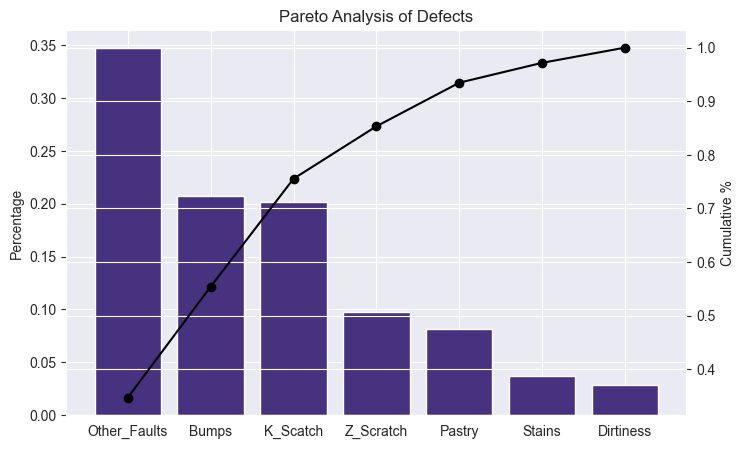

In [18]:
# Measure defect proportion in the dataset
defect_cols_names = df.columns[-7:]
defect_cols = df[defect_cols_names]
defect_count = defect_cols.sum().sort_values(ascending=False)
defect_distribution = defect_count/ defect_count.sum()

defect_counts = defect_cols.sum().sort_values(ascending=False)
defect_pct = defect_counts / defect_counts.sum()
cum_pct = defect_pct.cumsum()

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(defect_counts.index, defect_pct)
ax1.set_ylabel("Percentage")

ax2 = ax1.twinx()
ax2.plot(defect_counts.index, cum_pct, marker="o", color="black")
ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis of Defects")
plt.xticks(rotation=45)
plt.show()




### 📌 Pareto Analysis

- The top 3 defect types account for the majority of defects:
  - Other_Faults (~35%)
  - Bumps (~21%)
  - K_Scratch (~20%)

### ⚙️ Engineering Interpretation

- Strong Pareto behavior is observed:
  - A few defect types dominate production losses  

### 🎯 Actionable Insight

- Focusing improvement efforts on these 3 defects could significantly reduce total defect rates  
- This provides a clear prioritization for process engineering efforts  


Modify to look at distributions per defect type

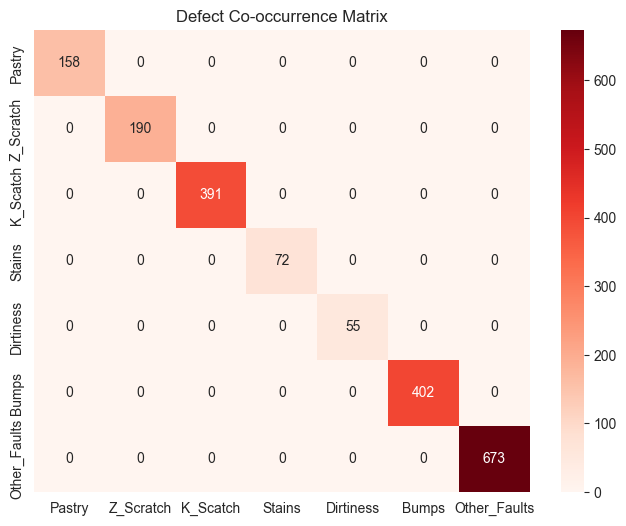

In [21]:

co_occurrence = df[defect_cols_names].T.dot(df[defect_cols_names])

plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, annot=True, fmt=".0f", cmap="Reds")
plt.title("Defect Co-occurrence Matrix")
plt.show()

### 🔗 Defect Co-occurrence Insight

- Defects appear to be mutually exclusive (no significant co-occurrence observed)

### ⚙️ Engineering Interpretation

- Each observation is associated with a **single dominant defect type**
- This suggests:
  - Distinct and independent failure mechanisms  
  - Clear separation between defect categories  

### 🎯 Actionable Insight

- Each defect type should be analyzed independently  
- Process improvements can be targeted per defect without major overlap  

In [56]:
defect_count = defect_cols.sum().sort_values(ascending=False)
top_defects = defect_count.head(3).index

In [61]:
# Select only feature columns (exclude defects)
feature_cols = [col for col in df.columns if col not in defect_cols_names]

# Compute variability metrics
std_dev = df[feature_cols].std()
value_range = df[feature_cols].max() - df[feature_cols].min()

# Combine into a score
variability_score = std_dev * value_range

# Rank variables
top_features = variability_score.sort_values(ascending=False)
key_vars = top_features.head(5).index.tolist()

print("Selected key variables:", key_vars)

Selected key variables: ['Y_Maximum', 'Y_Minimum', 'Sum_of_Luminosity', 'Pixels_Areas', 'Y_Perimeter']


In [63]:
print("Analyzing top defects:", list(top_defects))
print("Analyzing key variables:", list(key_vars))

Analyzing top defects: ['Other_Faults', 'Bumps', 'K_Scatch']
Analyzing key variables: ['Y_Maximum', 'Y_Minimum', 'Sum_of_Luminosity', 'Pixels_Areas', 'Y_Perimeter']


### ⚙️ Variable Selection Rationale

Variables were selected based on process variability, as variation is a primary driver of defects in industrial systems.

High variability indicates:
- Lack of control  
- Increased risk of quality issues  

This aligns with Six Sigma principles, where reducing variation improves quality.

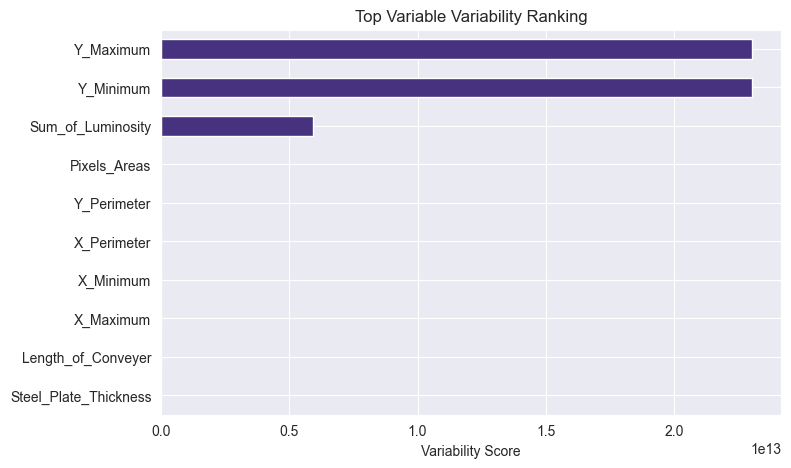

In [64]:
top_features.head(10).sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Top Variable Variability Ranking")
plt.xlabel("Variability Score")
plt.show()

### 🎯 Selected Critical Process Variables

The following variables exhibit the highest variability:

- **Y_Maximum**
- **Y_Minimum**
- **Sum_of_Luminosity**
- **Pixels_Areas**
- **Y_Perimeter**

### ⚙️ Engineering Interpretation

- These variables are likely:
  - Poorly controlled  
  - Sensitive to disturbances  
  - Driving process instability  

### 🚀 Why This Matters

- In industrial processes, reducing variability in key variables:
  - Directly improves product consistency  
  - Reduces defect rates  

### 🔍 Process Variable Behavior by Defect Type

This analysis compares the distribution of key process variables between:

- Observations where a defect is present  
- Observations where it is absent  

This helps identify variables that may be driving specific defect formation.

### ⚙️ Engineering Interpretation

- Several variables show clear separation between defective and non-defective conditions
- This indicates strong relationships between:
  - Process settings  
  - Defect generation  

### 🎯 Actionable Insight

- Variables with clear separation should be:
  - Prioritized for tighter control  
  - Monitored using SPC in the next phase  

### ⚙️ Engineering Interpretation

- The presence of distinct clusters suggests:
  - Multiple defect generation patterns  
  - Different underlying process conditions  

### 🎯 Actionable Insight

- Each cluster should be analyzed separately in relation to process variables  
- This enables more targeted and effective process optimization  

In [65]:
# Create single defect label per observation
df["defect_type"] = df[defect_cols_names].idxmax(axis=1)

df["defect_type"].value_counts()

defect_type
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64

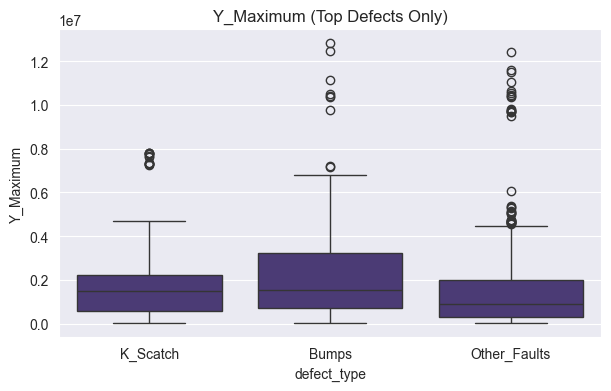

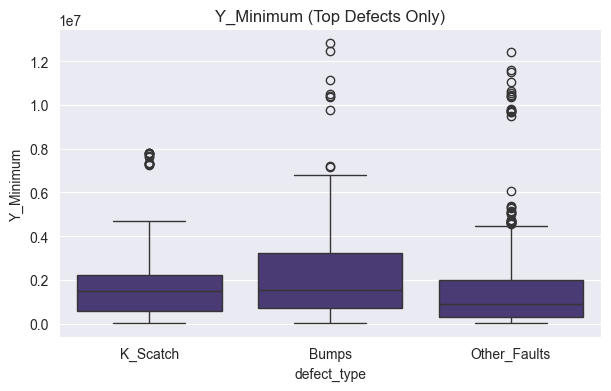

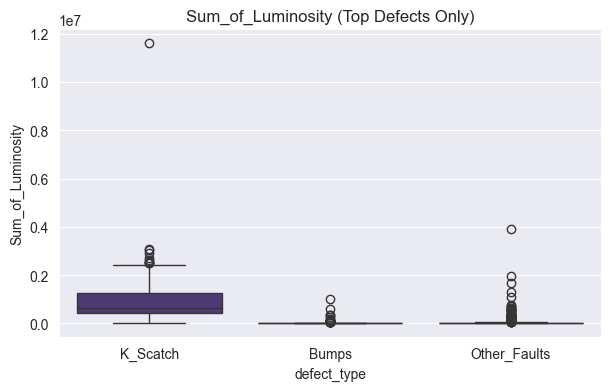

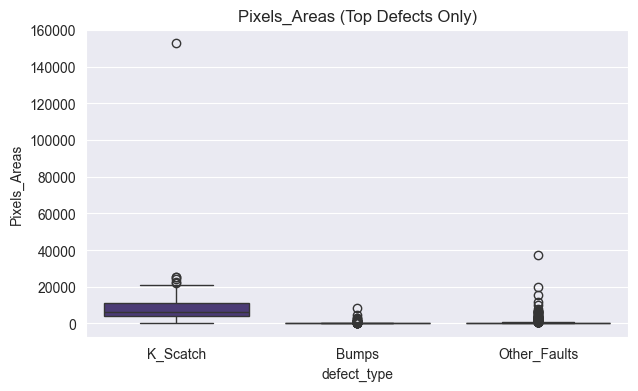

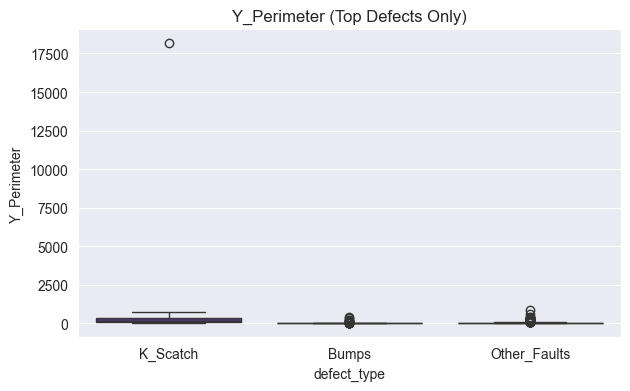

In [68]:
top_defects = df["defect_type"].value_counts().head(3).index

df_top = df[df["defect_type"].isin(top_defects)]

for var in key_vars:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="defect_type", y=var, data=df_top)
    plt.title(f"{var} (Top Defects Only)")
    plt.show()

### 🔍 Process Behavior by Defect Type

- Significant differences are observed in key variables across defect types  
- Some defects are associated with:
  - Higher median values  
  - Greater variability  
  - Presence of extreme values (outliers)  

### ⚙️ Engineering Interpretation

- This indicates that:
  - Different defects are generated under different process conditions  
  - Each defect likely corresponds to a specific failure mechanism  

### 🎯 Actionable Insight

- Define optimal operating ranges for each variable  
- Identify abnormal ranges linked to specific defects  
- Use this information to guide process adjustments

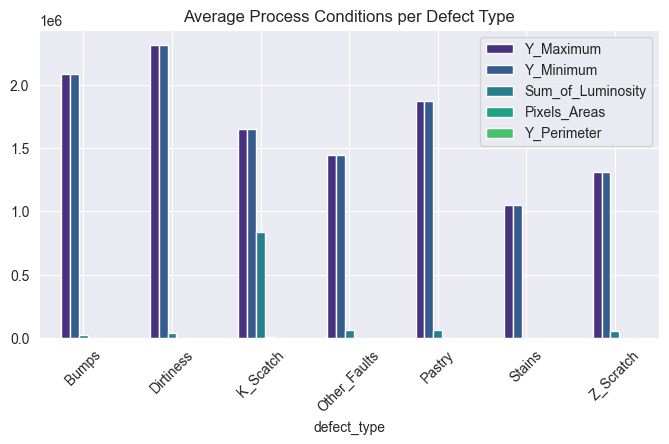

In [70]:
mean_profile = df.groupby("defect_type")[key_vars].mean()

mean_profile.plot(kind="bar", figsize=(8,4))
plt.title("Average Process Conditions per Defect Type")
plt.xticks(rotation=45)
plt.show()

## 🧠 Root Cause Hypothesis

Based on the analysis:

- Process variables show clear differentiation across defect types  
- High variability variables are strongly associated with defect formation  

### ⚙️ Engineering Hypothesis

- Defects are generated due to:
  - Operation outside optimal variable ranges  
  - Instability in key process parameters  

- Each defect type corresponds to a:
  - Specific failure mode  
  - Distinct process condition  

### 🚀 Next Step

- Apply Statistical Process Control (SPC) to:
  - Monitor critical variables  
  - Detect out-of-control conditions  
  - Improve process stability  
  